In [1]:
# Create a folder for your internship project
import os
os.makedirs('CodeAlpha_CreditScoring', exist_ok=True)
print("✅ Created project folder")

✅ Created project folder


In [2]:
# Download a credit scoring dataset
import pandas as pd
import numpy as np

In [3]:
# Better: Let's use the German Credit Dataset
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data -O CodeAlpha_CreditScoring/german_credit.data

print("✅ Dataset downloaded!")

✅ Dataset downloaded!


'wget' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
# Download the German Credit Dataset using Python
import urllib.request
import os


In [5]:
# Create folder if it doesn't exist
os.makedirs('CodeAlpha_CreditScoring', exist_ok=True)

In [6]:
# Download the file
print("📥 Downloading German Credit Dataset...")
urllib.request.urlretrieve(url, "CodeAlpha_CreditScoring/german_credit.data")
print("✅ Dataset downloaded successfully!")

📥 Downloading German Credit Dataset...


NameError: name 'url' is not defined

In [7]:
# Define the URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
print("✅ URL defined!")

✅ URL defined!


In [8]:
import urllib.request
import os

In [9]:
# Make sure folder exists
os.makedirs('CodeAlpha_CreditScoring', exist_ok=True)

In [10]:
# Download the file
print("📥 Downloading German Credit Dataset...")
urllib.request.urlretrieve(url, "CodeAlpha_CreditScoring/german_credit.data")
print("✅ Dataset downloaded successfully!")

📥 Downloading German Credit Dataset...
✅ Dataset downloaded successfully!


In [11]:
# Check the file
file_path = "CodeAlpha_CreditScoring/german_credit.data"
if os.path.exists(file_path):
    file_size = os.path.getsize(file_path) / 1024
    print(f"📁 File saved to: {file_path}")
    print(f"📊 File size: {file_size:.1f} KB")

📁 File saved to: CodeAlpha_CreditScoring/german_credit.data
📊 File size: 77.9 KB


In [12]:
import pandas as pd
import numpy as np

In [13]:
# Define column names
column_names = [
    'existing_checking', 'duration', 'credit_history', 'purpose', 
    'credit_amount', 'savings', 'employment', 'installment_rate',
    'personal_status', 'other_debtors', 'present_residence', 
    'property', 'age', 'other_installment', 'housing', 
    'existing_credits', 'job', 'num_liable', 'telephone', 
    'foreign_worker', 'credit_risk'
]


In [14]:
# Load the dataset
df = pd.read_csv('CodeAlpha_CreditScoring/german_credit.data', 
                 sep=' ', names=column_names, header=None)

print("✅ Dataset loaded successfully!")
print(f"📊 Shape: {df.shape}")
print(f"\n👀 First 5 rows:")
print(df.head())

print(f"\n📊 Credit Risk Distribution:")
print(df['credit_risk'].value_counts())
# 1 = Good credit, 2 = Bad credit

✅ Dataset loaded successfully!
📊 Shape: (1000, 21)

👀 First 5 rows:
  existing_checking  duration credit_history purpose  credit_amount savings  \
0               A11         6            A34     A43           1169     A65   
1               A12        48            A32     A43           5951     A61   
2               A14        12            A34     A46           2096     A61   
3               A11        42            A32     A42           7882     A61   
4               A11        24            A33     A40           4870     A61   

  employment  installment_rate personal_status other_debtors  ...  property  \
0        A75                 4             A93          A101  ...      A121   
1        A73                 2             A92          A101  ...      A121   
2        A74                 2             A93          A101  ...      A121   
3        A74                 2             A93          A103  ...      A122   
4        A73                 3             A93          A101  

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# Load the data
column_names = [
    'existing_checking', 'duration', 'credit_history', 'purpose', 
    'credit_amount', 'savings', 'employment', 'installment_rate',
    'personal_status', 'other_debtors', 'present_residence', 
    'property', 'age', 'other_installment', 'housing', 
    'existing_credits', 'job', 'num_liable', 'telephone', 
    'foreign_worker', 'credit_risk'
]

df = pd.read_csv('CodeAlpha_CreditScoring/german_credit.data', 
                 sep=' ', names=column_names, header=None)

print("📊 DATASET OVERVIEW")
print("=" * 50)
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nData Types:")
print(df.dtypes)

print(f"\nTarget Distribution (1=Good, 2=Bad):")
print(df['credit_risk'].value_counts())

📊 DATASET OVERVIEW
Shape: (1000, 21)

First 5 rows:
  existing_checking  duration credit_history purpose  credit_amount savings  \
0               A11         6            A34     A43           1169     A65   
1               A12        48            A32     A43           5951     A61   
2               A14        12            A34     A46           2096     A61   
3               A11        42            A32     A42           7882     A61   
4               A11        24            A33     A40           4870     A61   

  employment  installment_rate personal_status other_debtors  ...  property  \
0        A75                 4             A93          A101  ...      A121   
1        A73                 2             A92          A101  ...      A121   
2        A74                 2             A93          A101  ...      A121   
3        A74                 2             A93          A103  ...      A122   
4        A73                 3             A93          A101  ...      A124   

In [17]:
# Convert target to binary (0=good, 1=bad) for better modeling
df['credit_risk'] = df['credit_risk'] - 1

# Create new features from existing ones
print("🔧 FEATURE ENGINEERING")
print("=" * 50)

# 1. Create debt-to-income ratio proxy
# (using credit_amount and duration as proxy for income)
df['debt_to_duration'] = df['credit_amount'] / df['duration']
print("✅ Created: debt_to_duration (credit amount per month)")

# 2. Age groups (categorize age)
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 50, 100], 
                          labels=['young', 'young_adult', 'adult', 'senior'])
print("✅ Created: age_group")

# 3. Credit amount groups
df['amount_group'] = pd.cut(df['credit_amount'], bins=4, 
                             labels=['very_low', 'low', 'medium', 'high'])
print("✅ Created: amount_group")

print(f"\nNew columns added: {df.columns[-3:].tolist()}")

🔧 FEATURE ENGINEERING
✅ Created: debt_to_duration (credit amount per month)
✅ Created: age_group
✅ Created: amount_group

New columns added: ['debt_to_duration', 'age_group', 'amount_group']


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separate features and target
X = df.drop('credit_risk', axis=1)
y = df['credit_risk']

# Identify column types
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

print("📊 DATA PREPARATION")
print("=" * 50)
print(f"Numerical features: {numerical_cols.tolist()}")
print(f"Categorical features: {categorical_cols.tolist()}")

# Create preprocessing pipeline
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

📊 DATA PREPARATION
Numerical features: ['duration', 'credit_amount', 'installment_rate', 'present_residence', 'age', 'existing_credits', 'num_liable', 'debt_to_duration']
Categorical features: ['existing_checking', 'credit_history', 'purpose', 'savings', 'employment', 'personal_status', 'other_debtors', 'property', 'other_installment', 'housing', 'job', 'telephone', 'foreign_worker', 'age_group', 'amount_group']

Training set: (800, 23)
Testing set: (200, 23)


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Create models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Train and evaluate each model
results = {}

print("🚀 TRAINING MODELS")
print("=" * 50)

for name, model in models.items():
    print(f"\n📊 Training {name}...")
    
    # Create pipeline with preprocessor and model
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Calculate metrics (EXACTLY as task requires)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Store results
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }
    
    print(f"✅ {name} trained!")
    print(f"   Accuracy: {accuracy:.3f}")
    print(f"   Precision: {precision:.3f}")
    print(f"   Recall: {recall:.3f}")
    print(f"   F1-Score: {f1:.3f}")
    print(f"   ROC-AUC: {roc_auc:.3f}")

🚀 TRAINING MODELS

📊 Training Logistic Regression...
✅ Logistic Regression trained!
   Accuracy: 0.765
   Precision: 0.627
   Recall: 0.533
   F1-Score: 0.577
   ROC-AUC: 0.807

📊 Training Decision Tree...
✅ Decision Tree trained!
   Accuracy: 0.650
   Precision: 0.422
   Recall: 0.450
   F1-Score: 0.435
   ROC-AUC: 0.593

📊 Training Random Forest...
✅ Random Forest trained!
   Accuracy: 0.750
   Precision: 0.647
   Recall: 0.367
   F1-Score: 0.468
   ROC-AUC: 0.800



📊 MODEL COMPARISON
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.765      0.627   0.533     0.577    0.807
Decision Tree           0.650      0.422   0.450     0.435    0.593
Random Forest           0.750      0.647   0.367     0.468    0.800


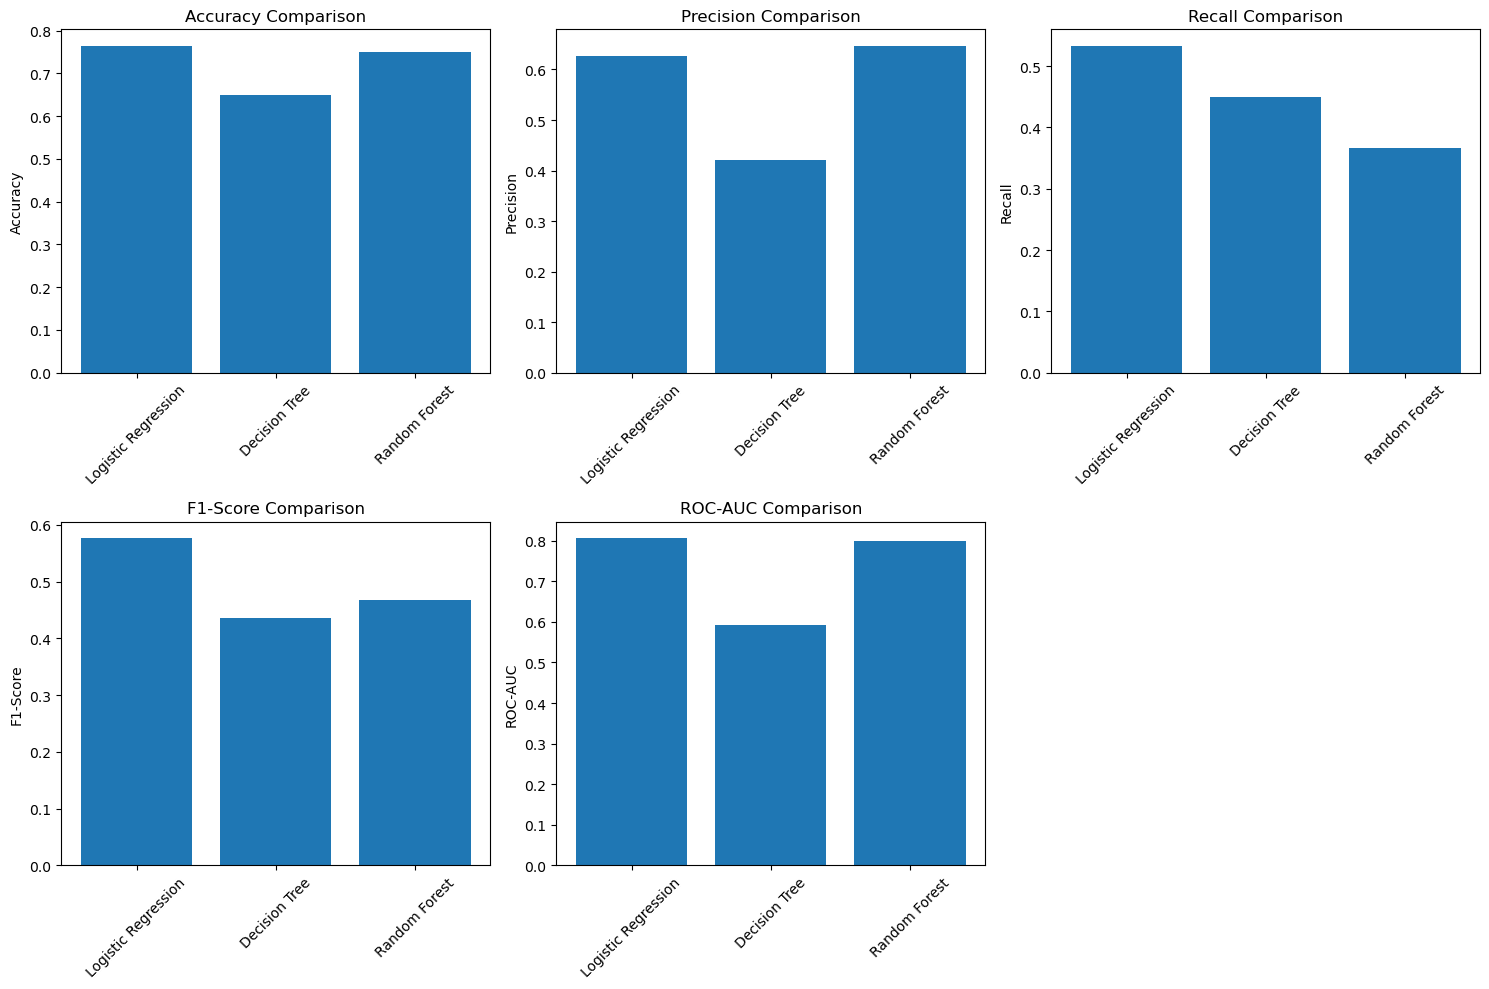


🏆 Best model based on F1-Score: Logistic Regression


In [20]:
# Create comparison DataFrame
results_df = pd.DataFrame(results).T
print("\n📊 MODEL COMPARISON")
print("=" * 50)
print(results_df.round(3))

# Visualize comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
for i, metric in enumerate(metrics):
    axes[i].bar(results_df.index, results_df[metric])
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)

# Hide the 6th subplot (since we only have 5 metrics)
axes[5].set_visible(False)

plt.tight_layout()
plt.show()

# Find best model
best_model = results_df['F1-Score'].idxmax()
print(f"\n🏆 Best model based on F1-Score: {best_model}")

🌟 TOP 10 MOST IMPORTANT FEATURES
                  feature  importance
7        debt_to_duration    0.081350
1           credit_amount    0.079633
0                duration    0.065279
4                     age    0.064328
11  existing_checking_A14    0.047237
8   existing_checking_A11    0.032429
3       present_residence    0.029683
2        installment_rate    0.028761
27            savings_A61    0.019610
16     credit_history_A34    0.018818


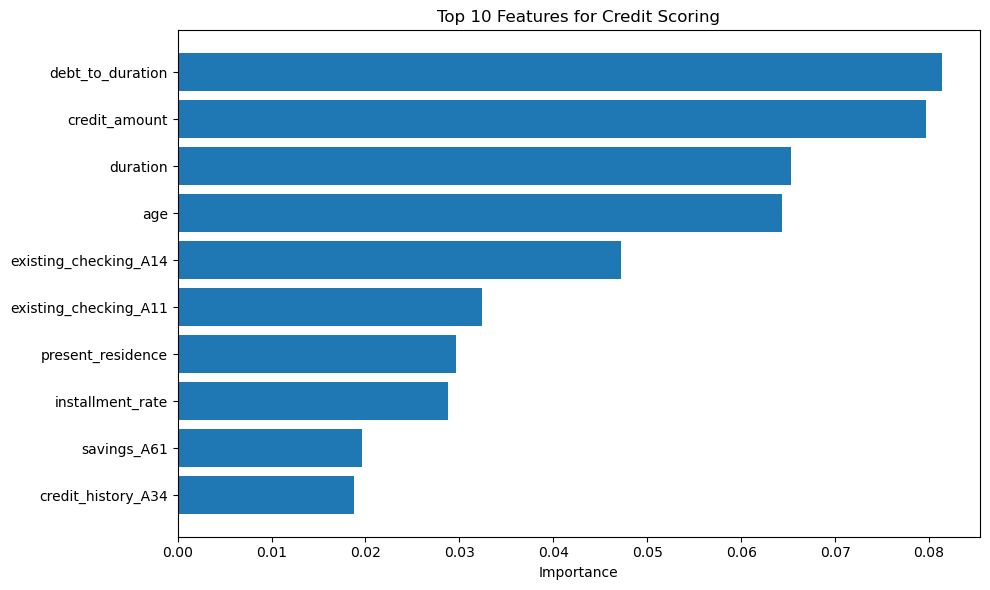

In [21]:
# Train Random Forest to see feature importance
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)

# Get feature names after preprocessing
feature_names = (numerical_cols.tolist() + 
                 rf_pipeline.named_steps['preprocessor']
                 .named_transformers_['cat']
                 .get_feature_names_out(categorical_cols).tolist())

# Get feature importances
importances = rf_pipeline.named_steps['classifier'].feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    'feature': feature_names[:len(importances)],
    'importance': importances
}).sort_values('importance', ascending=False)

print("🌟 TOP 10 MOST IMPORTANT FEATURES")
print("=" * 50)
print(feature_importance.head(10))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance.head(10)['feature'], feature_importance.head(10)['importance'])
plt.xlabel('Importance')
plt.title('Top 10 Features for Credit Scoring')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [22]:
import joblib

# Save the best model (Random Forest usually performs well)
best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

best_pipeline.fit(X_train, y_train)

# Save model
joblib.dump(best_pipeline, 'CodeAlpha_CreditScoring/credit_scoring_model.pkl')
print("✅ Model saved as 'credit_scoring_model.pkl'")

# Save results
results_df.to_csv('CodeAlpha_CreditScoring/model_results.csv')
print("✅ Results saved as 'model_results.csv'")

✅ Model saved as 'credit_scoring_model.pkl'
✅ Results saved as 'model_results.csv'


In [23]:
import pandas as pd
import os

# Load your results file
results_path = 'CodeAlpha_CreditScoring/model_results.csv'
if os.path.exists(results_path):
    df_results = pd.read_csv(results_path)
    print("📊 YOUR MODEL RESULTS:")
    print(df_results)
else:
    print("❌ Results file not found")

📊 YOUR MODEL RESULTS:
            Unnamed: 0  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression     0.765   0.627451  0.533333  0.576577  0.806548
1        Decision Tree     0.650   0.421875  0.450000  0.435484  0.592857
2        Random Forest     0.750   0.647059  0.366667  0.468085  0.800357
